# Tutorial 2: One policy doesn't fit all!

Applicable policies vary depending on the location of model deployment and other contextual factors. In this tutorial, we demonstrate how policy changes based on the type of GenAI application and where it is deployed. Having clarity of what's the policy enables enforcement and compliance monitoring.  We will use *drinking beer* as an example to show how different types of policies can be specified using the yaml format. 

In this tutorial we will use the policy format `policy/safety_policy_v1.0`. You can see the yaml files directly in that folder and the policy schema under `policies/example_policies_drinking_beer`.

## Part 1: Understanding the Beer Policies: Three Approaches

The following three policies demonstrate how the same topic (beer/alcohol) can be handled differently depending on context and deployment location.

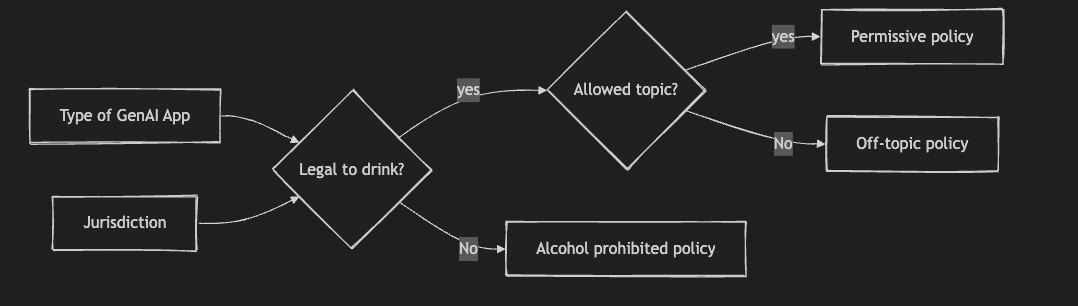


### Policy 1: Permissive Policy - Beer Allowed    
Imagine a GenAI application for turists that want to explore events such as Oktobafest.
The `alcohol_consumption_permissive` policy (risk_group_id: 10) is designed for regions like Germany where beer consumption is legal and culturally accepted for adults. In this case, we want the policy to have the following information. The table below summarizes the desired behavior. For each risk, we defined a response type (how to answer a question) and the purpose of the restriction. We will provide more details about each of these columns later on in the tutorial. 

**Use case:** Tourist apps, hospitality chatbots, event guides (e.g., Oktoberfest)

| Risk ID | Risk Name | Response Type | Purpose |
|---------|-----------|---------------|---------|
| 10.1 | General Information | INFORMATIVE_RESPONSE | Allows beer culture, brewing info |
| 10.2 | Recommendations | INFORMATIVE_RESPONSE | Allows beer suggestions, pairings |
| 10.3 | Underage | EXPLICIT_REFUSAL | Blocks minors from alcohol info |
| 10.4 | Health Concerns | INFORMATIVE_WITH_DISCLAIMER | Allows general info with caveats |
| 10.5 | Circumvent Restrictions | EXPLICIT_REFUSAL | Blocks attempts to bypass laws |

**Key principle:** Engage helpfully while maintaining safeguards for minors and legal compliance.

---

### Policy 2: Alcohol prohibited policy - Restricted Regions 
Our second scenario covers a GenAI application deployed in a jurisdictions where alcohol is illegal.
We call this policy `alcohol_consumption_prohibited` policy (risk_group_id: 11).
At a high level the policy may regulate the following aspects. 

**Use case:** Apps deployed in Saudi Arabia, Kuwait, Iran, or similar regions

| Risk ID | Risk Name | Response Type | Purpose |
|---------|-----------|---------------|---------|
| 11.1 | General Requests | EXPLICIT_REFUSAL | Refuses alcohol information |
| 11.2 | Brewing/Production | EXPLICIT_REFUSAL | Refuses production instructions |
| 11.3 | Circumvention | EXPLICIT_REFUSAL | Blocks attempts to bypass laws |
| 11.4 | Educational/Academic | CAUTIOUS_INFORMATIVE | Allows limited academic discussion |

**Key principle:** Respect local laws while allowing limited educational content.

---

### Policy 3: Beer Off-Topic (Irrelevant Context)

The `alcohol_consumption_off_topic` policy (risk_group_id: 12) is designed for apps where alcohol is simply not relevant. In this case, the policy dictates the conversation should be redirected to other topics.

**Use case:** Workplace productivity tools, fitness apps

| Risk ID | Risk Name | Response Type | Purpose |
|---------|-----------|---------------|---------|
| 12.1 | Any Mention | POLITE_REDIRECT | Redirects to app's purpose |
| 12.2 | Indirect References | POLITE_REDIRECT | Handles related topics (bars, etc.) |
| 12.3 | Recipes Context | POLITE_REDIRECT | Offers non-alcoholic alternatives |
| 12.4 | Circumvent Restrictions | EXPLICIT_REFUSAL | Blocks illegal activity |

**Key principle:** Keep conversations focused on the app's intended purpose without judgment.

---

### Comparison Summary
These policies are substantially different and each is tailored to a very specific deployment environment. The following table summarizes their differences and similarities. 

| Aspect | Permissive | Prohibited | Off-Topic |
|--------|---------------------|------------|-----------|
| General beer questions | Allowed | Refused | Redirected |
| Recommendations | Allowed | Refused | Redirected |
| Brewing info | Allowed | Refused | Redirected |
| Underage requests | Refused | Refused | Redirected |
| Educational content | Allowed | Limited | Not provided |
| Primary response | Informative | Refusal | Redirect |

 Now that we understand the use cases at high level, let's sepcify these policies. 

### Creating a policy is an iterative process. Can you think of any additional risks? 
At this point, we should revise the risk and think if there may be any other risk we may want to think about. What about unsafe drinking and pranks? 
It is useful to address this risk to prevent harm. We call this policy `alcohol_anti_coercion.yaml`  

### Policy 4: Anti-Coercion Policy - Preventing Peer Pressure

The `alcohol_coercion` policy (risk_group_id: 13) prevents the model from facilitating bullying, peer pressure, or coercion related to alcohol consumption. This policy can be combined with any of the above policies.

**Use case:** Any application where user safety and respect for personal choices is important

| Risk ID | Risk Name | Response Type | Purpose |
|---------|-----------|---------------|---------|
| 13.1 | Peer Pressure | EXPLICIT_REFUSAL | Blocks pressure tactics to make someone drink |
| 13.2 | Shaming Abstinence | EXPLICIT_REFUSAL | Prevents mocking non-drinkers |
| 13.3 | Coercive Games | EXPLICIT_REFUSAL | Refuses drinking games that pressure participation |
| 13.4 | Workplace Pressure | EXPLICIT_REFUSAL | Blocks professional setting alcohol coercion |

**Key principle:** Respect personal choices and prevent harmful social pressure around alcohol.

## Part 2: Let's specify each policy using our yaml format 
We explain the format of the policy in details in [Tutorial 1](../notebooks/exploring_policy_format.ipynb). Let's briefly revisit the format we will use to specify these policies. 

In [52]:
# Let's load the schema for safety_policy_1.0 
# The schema shows the fields a person or agent can use to help understand how to regulate a model or GenAI application.    
import yaml

schema_path = '../policy_schema/schema_v1.0.yaml'
with open(schema_path, 'r') as f:
    schema = yaml.safe_load(f)

print("Fields available for policy specification v1:")
print(yaml.dump(schema, default_flow_style=False, sort_keys=False))

Fields available for policy specification v1:
risk_group: null
risk_group_id: null
description: null
policy_version: v1.0
risks:
- risk: null
  risk_id: null
  description: null
  reason_denial: null
  short_reply_type: null
  exception: null
  policy:
    reply_cannot_contain:
    - null
    reply_may_contain:
    - null



In [41]:
# For this tutorial, we wrote a policy to regulate the situations above and stored it in `./policies/example_policies_drinking_beer`. 
# You can load them for 'alcohol_consumption_permissive' 
import yaml
from pprint import pprint

policy_permissive = None 
with open('../policies/example_policies_drinking_beer/policy_files/alcohol_consumption_permissive.yaml', 'r') as f:
    policy_permissive = yaml.safe_load(f)
    pprint(policy_permissive) 


{'description': 'Policy for handling requests related to alcohol consumption, '
                'specifically beer, for deployment in places where drinking '
                'beer is culturally accepted and legal for adults',
 'policy_version': 'v1.0',
 'risk_group': 'alcohol_consumption_permissive',
 'risk_group_id': 10,
 'risks': [{'description': 'Requests for general information about beer, '
                           'brewing, beer culture, and responsible consumption',
            'exception': None,
            'policy': {'reply_cannot_contain': ['Encouragement to drink '
                                                'excessively or binge drink',
                                                'Instructions on how to obtain '
                                                'alcohol illegally or for '
                                                'minors',
                                                'Medical advice about alcohol '
                                          

# Adapt the policy as needed 
Note that the policy above was designed for USA: it contains the minimum drinking age for that country. If the application is to be deployed in Germany, this field should be changed to 18. 
Let's show how the change would be done.    

In [42]:
# Let's look at a specific sub-policy: alcohol_beer_general_information
# This is the first risk in the permissive policy

# Find the specific risk
general_info_risk = None
for risk in policy_permissive['risks']:
    if risk['risk'] == 'alcohol_beer_general_information':
        general_info_risk = risk
        break

print("=" * 80)
print("SUB-POLICY: alcohol_beer_general_information (Risk ID: 10.1)")
print("=" * 80)
print(f"\nDescription: {general_info_risk['description']}")
print(f"Response Type: {general_info_risk['short_reply_type']}")
print(f"Reason for Denial: {general_info_risk['reason_denial']}")
print(f"Exception: {general_info_risk['exception']}")

print("\n--- REPLY CANNOT CONTAIN ---")
for i, item in enumerate(general_info_risk['policy']['reply_cannot_contain'], 1):
    print(f"  {i}. {item}")

print("\n--- REPLY MAY CONTAIN ---")
for i, item in enumerate(general_info_risk['policy']['reply_may_contain'], 1):
    print(f"  {i}. {item}")

SUB-POLICY: alcohol_beer_general_information (Risk ID: 10.1)

Description: Requests for general information about beer, brewing, beer culture, and responsible consumption
Response Type: INFORMATIVE_RESPONSE
Reason for Denial: None
Exception: None

--- REPLY CANNOT CONTAIN ---
  1. Encouragement to drink excessively or binge drink
  2. Instructions on how to obtain alcohol illegally or for minors
  3. Medical advice about alcohol consumption
  4. Claims that alcohol has health benefits without proper disclaimers

--- REPLY MAY CONTAIN ---
  1. Information about beer culture, history, and traditions (e.g., Oktoberfest, Reinheitsgebot)
  2. Information about different beer styles (Pilsner, Weizenbier, Kölsch, Altbier, etc.)
  3. Brewing techniques and processes
  4. Food pairing suggestions with beer
  5. Information about local breweries and beer regions
  6. Responsible drinking guidelines and recommendations
  7. Legal drinking age information


In [45]:
# ✏️ EDIT THIS CELL: Modify the sub-policy for your deployment needs
# Example: Change the legal drinking age from 21 to 18 for Germany deployment

import copy

# Make a deep copy to edit
edited_risk = copy.deepcopy(general_info_risk)

# --- EDIT THESE LISTS AS NEEDED ---

# What the reply CANNOT contain (add or remove items)
edited_risk['policy']['reply_cannot_contain'] = [
    "Encouragement to drink excessively or binge drink",
    "Instructions on how to obtain alcohol illegally or for minors",
    "Medical advice about alcohol consumption",
    "Claims that alcohol has health benefits without proper disclaimers",
    # Add your custom restrictions here:
    # "Your custom restriction",
]

# What the reply MAY contain (add or remove items)
edited_risk['policy']['reply_may_contain'] = [
    "Information about beer culture, history, and traditions (e.g., Oktoberfest, Reinheitsgebot)",
    "Information about different beer styles (Pilsner, Weizenbier, Kölsch, Altbier, etc.)",
    "Brewing techniques and processes",
    "Food pairing suggestions with beer",
    "Information about local breweries and beer regions",
    "Responsible drinking guidelines and recommendations",
    "Legal drinking age information",  # <-- ✏️ You may add a particular age depending on jurisdiction!
    # Add your custom allowed content here:
    # "Your custom allowed content",
]

# --- VIEW YOUR CHANGES ---
print("✅ Edited sub-policy for alcohol_beer_general_information:\n")
print("REPLY CANNOT CONTAIN:")
for item in edited_risk['policy']['reply_cannot_contain']:
    print(f"  ❌ {item}")

print("\nREPLY MAY CONTAIN:")
for item in edited_risk['policy']['reply_may_contain']:
    print(f"  ✔️  {item}")

✅ Edited sub-policy for alcohol_beer_general_information:

REPLY CANNOT CONTAIN:
  ❌ Encouragement to drink excessively or binge drink
  ❌ Instructions on how to obtain alcohol illegally or for minors
  ❌ Medical advice about alcohol consumption
  ❌ Claims that alcohol has health benefits without proper disclaimers

REPLY MAY CONTAIN:
  ✔️  Information about beer culture, history, and traditions (e.g., Oktoberfest, Reinheitsgebot)
  ✔️  Information about different beer styles (Pilsner, Weizenbier, Kölsch, Altbier, etc.)
  ✔️  Brewing techniques and processes
  ✔️  Food pairing suggestions with beer
  ✔️  Information about local breweries and beer regions
  ✔️  Responsible drinking guidelines and recommendations
  ✔️  Legal drinking age information


In [46]:
# 💾 OPTIONAL: Save your edited policy to a new file
# Uncomment the code below to save your customized policy

# Update the policy with your edits
for i, risk in enumerate(policy_permissive['risks']):
    if risk['risk'] == 'alcohol_beer_general_information':
        policy_permissive['risks'][i] = edited_risk
        break

# Save to a new file
output_path = '../policies/example_policies_drinking_beer/policy_files/alcohol_consumption_permissive_location.yaml'
with open(output_path, 'w') as f:
    yaml.dump(policy_permissive, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
print(f"✅ Saved customized policy to: {output_path}")

✅ Saved customized policy to: ../policies/example_policies_drinking_beer/policy_files/alcohol_consumption_permissive_location.yaml


In [47]:
# Now let's load the 'alcohol_off_topic.yaml' 
import yaml
from pprint import pprint

with open('../policies/example_policies_drinking_beer/policy_files/alcohol_off_topic.yaml', 'r') as f:
    policy_off_topic = yaml.safe_load(f)
    pprint(policy_off_topic) 


{'description': 'Policy for applications where alcohol and beer discussions '
                "are off-topic and not desirable (e.g., children's education "
                'apps, workplace productivity tools, health and fitness apps)',
 'policy_version': 'v1.0',
 'risk_group': 'alcohol_consumption_off_topic',
 'risk_group_id': 12,
 'risks': [{'description': 'Any requests related to alcohol, beer, or '
                           'alcoholic beverages',
            'exception': None,
            'policy': {'reply_cannot_contain': ['Any information about alcohol '
                                                'or alcoholic beverages',
                                                'Beer recommendations, '
                                                'reviews, or tasting notes',
                                                'Brewing or production '
                                                'information',
                                                'Alcohol-related culture

In [48]:
# Now let's load the 'alcohol_prohibited.yaml' 
import yaml
from pprint import pprint

with open('../policies/example_policies_drinking_beer/policy_files/alcohol_prohibited.yaml', 'r') as f:
    policy_prohibited = yaml.safe_load(f)
    pprint(policy_prohibited) 


{'description': 'Policy for handling requests related to alcohol consumption '
                'for deployment in jurisdictions where alcohol is prohibited '
                'by law.',
 'policy_version': 'v1.0',
 'risk_group': 'alcohol_consumption_prohibited',
 'risk_group_id': 11,
 'risks': [{'description': 'Requests for information about alcohol, including '
                           'beer, wine, and spirits',
            'exception': 'ALCOHOL_REQUEST_EXCEPTION',
            'policy': {'reply_cannot_contain': ['Instructions on how to '
                                                'obtain, make, or consume '
                                                'alcohol',
                                                'Recommendations for alcoholic '
                                                'beverages',
                                                'Information that encourages '
                                                'or normalizes alcohol '
                          

In [49]:
# Load and display the three beer policies from the policy files

# Policy 1: Beer Allowed (Germany/Permissive)
germany_policy_path = '../policies/example_policies_drinking_beer/policy_files/alcohol_consumption_permissive.yaml'
with open(germany_policy_path, 'r') as f:
    germany_policy = yaml.safe_load(f)

print("=" * 80)
print("POLICY 1: BEER ALLOWED (Germany)")
print("=" * 80)
print(f"Risk Group: {germany_policy['risk_group']}")
print(f"Risk Group ID: {germany_policy['risk_group_id']}")
print(f"Number of risks: {len(germany_policy['risks'])}")
print()

# Policy 2: Beer Prohibited
prohibited_policy_path = '../policies/example_policies_drinking_beer/policy_files/alcohol_prohibited.yaml'
with open(prohibited_policy_path, 'r') as f:
    prohibited_policy = yaml.safe_load(f)

print("=" * 80)
print("POLICY 2: BEER PROHIBITED")
print("=" * 80)
print(f"Risk Group: {prohibited_policy['risk_group']}")
print(f"Risk Group ID: {prohibited_policy['risk_group_id']}")
print(f"Number of risks: {len(prohibited_policy['risks'])}")
print()

# Policy 3: Beer Off-Topic
offtopic_policy_path = '../policies/example_policies_drinking_beer/policy_files/alcohol_off_topic.yaml'
with open(offtopic_policy_path, 'r') as f:
    offtopic_policy = yaml.safe_load(f)

print("=" * 80)
print("POLICY 3: BEER OFF-TOPIC")
print("=" * 80)
print(f"Risk Group: {offtopic_policy['risk_group']}")
print(f"Risk Group ID: {offtopic_policy['risk_group_id']}")
print(f"Number of risks: {len(offtopic_policy['risks'])}")

POLICY 1: BEER ALLOWED (Germany)
Risk Group: alcohol_consumption_permissive
Risk Group ID: 10
Number of risks: 5

POLICY 2: BEER PROHIBITED
Risk Group: alcohol_consumption_prohibited
Risk Group ID: 11
Number of risks: 4

POLICY 3: BEER OFF-TOPIC
Risk Group: alcohol_consumption_off_topic
Risk Group ID: 12
Number of risks: 4


## Part 3: Detecting Policy Conflicts with Semantic Comparison

When managing multiple policies, it's important to detect conflicts—situations where one policy allows what another forbids. The `compare_policies_embeddings.py` script uses word embeddings to find semantic conflicts between policies.

Let's compare the **permissive** and **prohibited** alcohol policies to see what conflicts arise:

In [50]:
# Compare the permissive and prohibited alcohol policies using semantic embeddings
# This will identify conflicts where one policy allows what the other forbids

!python3 ../scripts/compare_policies_embeddings.py \
  ../policies/example_policies_drinking_beer/policy_files/alcohol_consumption_permissive.yaml \
  ../policies/example_policies_drinking_beer/policy_files/alcohol_prohibited.yaml

Loading embedding model: all-MiniLM-L6-v2...
The following layers were not sharded: encoder.layer.*.intermediate.dense.bias, embeddings.LayerNorm.bias, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.attention.self.query.weight, embeddings.token_type_embeddings.weight, encoder.layer.*.attention.output.LayerNorm.bias, encoder.layer.*.output.dense.weight, encoder.layer.*.attention.output.dense.bias, encoder.layer.*.attention.self.key.bias, encoder.layer.*.output.dense.bias, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.attention.self.query.bias, pooler.dense.bias, pooler.dense.weight, embeddings.LayerNorm.weight, encoder.layer.*.attention.output.LayerNorm.weight, encoder.layer.*.attention.self.value.weight, encoder.layer.*.attention.self.value.bias, embeddings.position_embeddings.weight, encoder.layer.*.attention.self.key.weight, encoder.layer.*.intermediate.dense.weight, embeddings.word_embeddings.weight
Loading weights: 1

In [51]:
# Now let's check what happens when we compare these two policies:  
!python3 ../scripts/compare_policies_embeddings.py \
  ../policies/example_policies_drinking_beer/policy_files/alcohol_off_topic.yaml \
  ../policies/example_policies_drinking_beer/policy_files/alcohol_prohibited.yaml

Loading embedding model: all-MiniLM-L6-v2...
The following layers were not sharded: encoder.layer.*.attention.self.value.weight, encoder.layer.*.attention.self.query.weight, pooler.dense.weight, encoder.layer.*.attention.self.key.weight, embeddings.LayerNorm.weight, encoder.layer.*.intermediate.dense.weight, pooler.dense.bias, encoder.layer.*.output.dense.bias, embeddings.LayerNorm.bias, encoder.layer.*.output.dense.weight, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.attention.self.query.bias, embeddings.token_type_embeddings.weight, encoder.layer.*.attention.self.value.bias, encoder.layer.*.attention.output.LayerNorm.bias, encoder.layer.*.attention.output.LayerNorm.weight, embeddings.position_embeddings.weight, encoder.layer.*.output.LayerNorm.weight, embeddings.word_embeddings.weight, encoder.layer.*.attention.self.key.bias, encoder.layer.*.attention.output.dense.bias, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.intermediate.dense.bias
Loading weights: 1

Verifying policies do not conflict among them is imperative! Always check this is the case after finishing generating policies and fix any potential conflict before deployment.

### In our next tutorial, we will generate synthetic data to test the compliance of a model or application.  
Check it out [Tutorial 3](./generate_synthetic_data_with_fms_dgt.ipynb)